<a href="https://colab.research.google.com/github/jawahirkhaleel/-jawahirkhaleel-/blob/main/Iran%E2%80%93Iraq_Earthquake_2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Iran–Iraq Earthquake (2017)

Part of the [InSAR.dev](https://insar.dev) Python ecosystem for SAR and InSAR processing. Free for personal and educational purposes; professional/funded use requires an active [license](https://pechnikov.dev).

### Resources
- Documentation and examples on [Patreon](https://www.patreon.com/pechnikov)
- Source code on [GitHub](https://github.com/InSARdev)
- Docker images on [DockerHub](https://hub.docker.com/r/insardev/)
- Updates on [LinkedIn](https://www.linkedin.com/in/alexey-pechnikov/)
- Tutorials on [YouTube](https://www.youtube.com/@alexeypechnikov)

© InSAR.dev, 2026


$\large\color{blue}{\text{Hint: Use menu Cell} \to \text{Run All or Runtime} \to \text{Complete All or Runtime} \to \text{Run All}}$
$\large\color{blue}{\text{(depending of your localization settings) to execute the entire notebook}}$

# Stage 1. InSAR.dev-PyGMTSAR: A Python package for InSAR pre-processing

Convert Sentinel-1 SLC data into a geocoded, cloud-ready Zarr dataset. The output can be hosted on GitHub or any file storage as a set of files or a single ZIP archive.

## Google Colab Installation

Install InSAR.dev Python libraries

In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  #!{sys.executable} -m pip install -qq --progress-bar off insardev-toolkit insardev-pygmtsar
  !{sys.executable} -m pip install -qq --progress-bar off \
    "insardev_toolkit  @ git+https://github.com/InSARdev/core@main#subdirectory=insardev_toolkit" \
    "insardev_pygmtsar @ git+https://github.com/InSARdev/core@main#subdirectory=insardev_pygmtsar"


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.


## Load and Setup Python Modules

In [ ]:
import numpy as np
import geopandas as gpd
import shapely
import json
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# import modules to be used in the notebook
from insardev_pygmtsar import S1
from insardev_toolkit import UI, EOF, ASF, Tiles, XYZTiles
UI('dark')

## Specify Directories

In [ ]:
# directory where Sentinel-1 bursts and orbits will be downloaded
DATADIR = 'iraniraq_data'
# path to the downloaded DEM file
DEM = f'{DATADIR}/dem.nc'
ZARRDIR = 'iraniraq_zarr'

## Download and Unpack Datasets

In [ ]:
# area
geojson = '''
{
  "type": "Feature",
  "geometry": {
    "type": "LineString",
    "coordinates": [[45.5, 35.3], [46.0, 34.7]]
  },
  "properties": {}
}
'''
AOI = gpd.GeoDataFrame.from_features([json.loads(geojson)])

In [ ]:
# find bursts
bursts = ASF.search(AOI, startTime='2017-11-11', stopTime='2017-11-17', flightDirection='A')
bursts

/usr/local/lib/python3.13/dist-packages/insardev_toolkit/ASF.py:3706: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geometry.type == 'LineString' and geometry.coords[0] == geometry.coords[-1]:
/usr/local/lib/python3.13/dist-packages/insardev_toolkit/ASF.py:3708: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geometry.type == 'Polygon':


,geometry,centerLat,centerLon,stopTime,fileID,flightDirection,pathNumber,processingLevel,url,startTime,...,processingDate,sensor,groupID,pgeVersion,fileName,beamModeType,s3Urls,burst,additionalUrls,fullBurstID
0,"POLYGON ((45.30782 35.15348, 45.75057 35.21292...",35.311984,45.724824,2017-11-17T14:59:51Z,S1_152708_IW3_20171117T145946_VV_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:48Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152708_IW3_20171117T145946_VV_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875261, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152708_IW3
1,"POLYGON ((45.30782 35.15348, 45.75057 35.21292...",35.311984,45.724824,2017-11-17T14:59:51Z,S1_152708_IW3_20171117T145946_VH_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:48Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152708_IW3_20171117T145946_VH_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875261, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152708_IW3
2,"POLYGON ((45.343 34.98755, 45.78481 35.04704, ...",35.146102,45.759107,2017-11-17T14:59:48Z,S1_152707_IW3_20171117T145944_VV_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:45Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152707_IW3_20171117T145944_VV_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875260, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152707_IW3
3,"POLYGON ((45.343 34.98755, 45.78481 35.04704, ...",35.146102,45.759107,2017-11-17T14:59:48Z,S1_152707_IW3_20171117T145944_VH_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:45Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152707_IW3_20171117T145944_VH_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875260, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152707_IW3
4,"POLYGON ((45.37813 34.82161, 45.81902 34.88115...",34.980213,45.793351,2017-11-17T14:59:45Z,S1_152706_IW3_20171117T145941_VV_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:42Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152706_IW3_20171117T145941_VV_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875259, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152706_IW3
5,"POLYGON ((45.37813 34.82161, 45.81902 34.88115...",34.980213,45.793351,2017-11-17T14:59:45Z,S1_152706_IW3_20171117T145941_VH_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:42Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152706_IW3_20171117T145941_VH_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875259, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152706_IW3
6,"POLYGON ((45.41322 34.65566, 45.85319 34.71525...",34.814317,45.827554,2017-11-17T14:59:42Z,S1_152705_IW3_20171117T145938_VV_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:39Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152705_IW3_20171117T145938_VV_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875258, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152705_IW3
7,"POLYGON ((45.41322 34.65566, 45.85319 34.71525...",34.814317,45.827554,2017-11-17T14:59:42Z,S1_152705_IW3_20171117T145938_VH_AFB8-BURST,ASCENDING,72,BURST,https://sentinel1-burst.asf.alaska.edu/S1B_IW_...,2017-11-17T14:59:39Z,...,None,C-SAR,S1B_IWDV_0108_0115_008323_072,002.84,S1_152705_IW3_20171117T145938_VH_AFB8-BURST.tiff,IW,[],"{'absoluteBurstID': 17875258, 'relativeBurstID...",[https://sentinel1-burst.asf.alaska.edu/S1B_IW...,072_152705_IW3
8,"POLYGON ((45.44826 34.48971, 45.88732 34.54934...",34.648414,45.861721,2017-11-17T14:59:40Z,S1_152704_IW3_20171117T145935_VV_AFB8-BURST,ASCENDING,72,BURST,https://

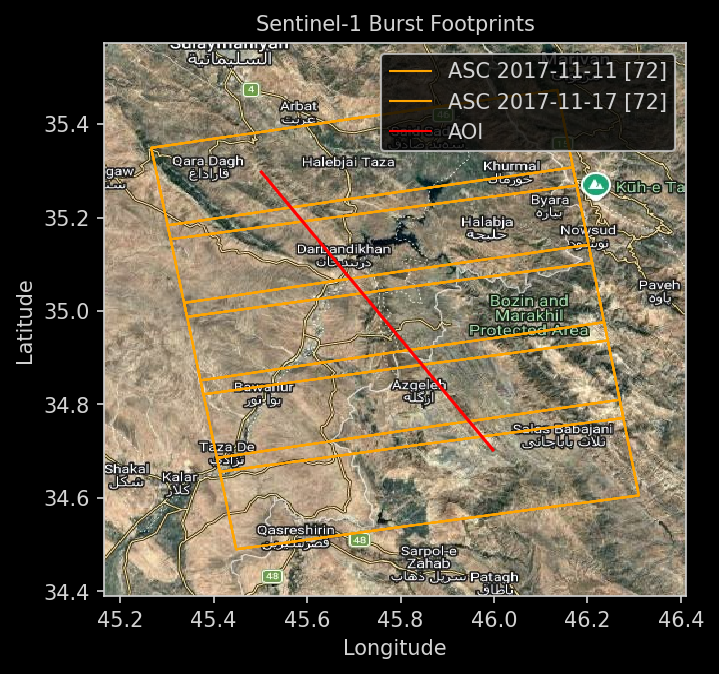

In [ ]:
plt.figure(figsize=(5,5))
# plot basemap
XYZTiles().download_googlesatellitehybrid(bursts.union_all().buffer(0.1), zoom=9).plot.imshow(ax=plt.gca())
# plot bursts
ASF.plot(bursts, ax=plt.gca())
# plot AOI
AOI.plot(ax=plt.gca(), color='red', edgecolor='darkgoldenrod', alpha=1, label='AOI')
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
# print bursts
BURSTS = bursts.fileID.tolist()
print (f'Bursts defined: {len(BURSTS)}')

Bursts defined: 20


In [ ]:
# leave empty to download bursts from InSARDEV global cache (faster) or use your ASF username and password
asf = ASF()
print(asf.download(DATADIR, BURSTS, polarization='VV'))

NOTE: Using insar.dev Cache API. Free for non-commercial use; license required for funded academic, institutional, or professional use.


                                         burst
0  S1_152708_IW3_20171117T145946_VV_AFB8-BURST
1  S1_152707_IW3_20171117T145944_VV_AFB8-BURST
2  S1_152706_IW3_20171117T145941_VV_AFB8-BURST
3  S1_152705_IW3_20171117T145938_VV_AFB8-BURST
4  S1_152704_IW3_20171117T145935_VV_AFB8-BURST
5  S1_152708_IW3_20171111T150028_VV_EE89-BURST
6  S1_152707_IW3_20171111T150026_VV_EE89-BURST
7  S1_152706_IW3_20171111T150023_VV_EE89-BURST
8  S1_152705_IW3_20171111T150020_VV_EE89-BURST
9  S1_152704_IW3_20171111T150017_VV_EE89-BURST


In [ ]:
# read the notices printed below carefully
s1 = S1(DATADIR)
s1


NOTE: Multiple path numbers found in the dataset: 72, 26.
NOTE: The following reference dates are available: 2017-11-11, 2017-11-17.
NOTE: Loaded 10 bursts.
NOTE: Orbits are not downloaded, baselines are undefined. Download the orbits and scan the data directory again.


Object S1 10 items
                                                                                         startTime  \
fullBurstID    polarization burst                                                                    
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST 2017-11-11 15:00:17.922687   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST 2017-11-17 14:59:35.910753   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST 2017-11-11 15:00:20.681244   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST 2017-11-17 14:59:38.669309   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST 2017-11-11 15:00:23.435689   
                            S1_152706_IW3_20171117T145941_VV_AFB8-BURST 2017-11-17 14:59:41.425810   
072_152707_IW3 VV           S1_152707_IW3_20171111T150026_VV_EE89-BURST 2017-11-11 15:00:26.194246   
                            S1_152707_IW3_20171117T145944_VV_AFB8-BURST 2017-11-17 14:59:44.180256   
072_152708_IW3 VV           S1_152708_IW3_20171111T150028_VV_EE89-BURST 2017-11-11 15:00:28.956913   
                            S1_152708_IW3_20171117T145946_VV_AFB8-BURST 2017-11-17 14:59:46.942923   

                                                                        flightDirection  \
fullBurstID    polarization burst                                                         
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST       Ascending   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST       Ascending   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST       Ascending   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST       Ascending   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST       Ascending   
                            S1_152706_IW3_20171117T145941_VV_AFB8-BURST       Ascending   
072_152707_IW3 VV           S1_152707_IW3_20171111T150026_VV_EE89-BURST       Ascending   
                            S1_152707_IW3_20171117T145944_VV_AFB8-BURST       Ascending   
072_152708_IW3 VV           S1_152708_IW3_20171111T150028_VV_EE89-BURST       Ascending   
                            S1_152708_IW3_20171117T145946_VV_AFB8-BURST       Ascending   

                                                                         pathNumber  \
fullBurstID    polarization burst                                                     
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST          72   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST          26   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST          72   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST          26   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST          72   
                            S1_152706_IW3_20171117T145941_VV_AFB8-BURST          26   
072_152707_IW3 VV           S1_152707_IW3_20171111T150026_VV_EE89-BURST          72   
                            S1_152707_IW3_20171117T145944_VV_AFB8-BURST          26   
072_152708_IW3 VV           S1_152708_IW3_20171111T150028_VV_EE89-BURST          72   
                            S1_152708_IW3_20171117T145946_VV_AFB8-BURST          26   

                                                                        subswath  \
fullBurstID    polarization burst                                                  
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST      IW3   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST      IW3   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST      IW3   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST      IW3   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST      IW3   
                            S1

In [ ]:
# scan the data directory for Sentinel-1 SLC bursts and download related orbits
EOF().download(DATADIR, s1)


,orbit
0,S1A_OPER_AUX_POEORB_OPOD_20210305T022048_V2017...
1,S1B_OPER_AUX_POEORB_OPOD_20210310T205724_V2017...


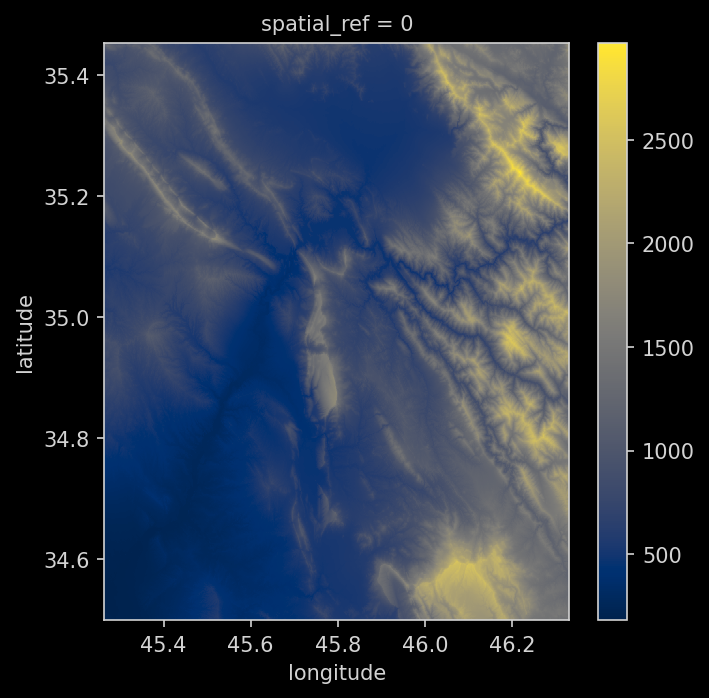

In [ ]:
plt.figure(figsize=(5,5))
# download Copernicus Global DEM 1 arc-second
Tiles().download_dem(s1, provider='GLO', filename=DEM)[::4,::4].plot.imshow(cmap='cividis')


## Preprocess Sentinel-1 SLC and Store as Geocoded Zarr

In [ ]:
# scan SLC bursts with DEM
s1 = S1(DATADIR, DEM=DEM)
s1


NOTE: Multiple path numbers found in the dataset: 72, 26.
NOTE: The following reference dates are available: 2017-11-11, 2017-11-17.
NOTE: Loaded 10 bursts.


Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  7.93it/s]


NOTE: 072_152704_IW3 baselines are measured from 2017-11-11.


Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  8.90it/s]


NOTE: 072_152705_IW3 baselines are measured from 2017-11-11.


...

Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  8.91it/s]


NOTE: 072_152707_IW3 baselines are measured from 2017-11-11.


Computing Baselines      : 100%|██████████| 2/2 [00:00<00:00,  8.99it/s]

NOTE: 072_152708_IW3 baselines are measured from 2017-11-11.


Object S1 10 items
                                                                                         startTime  \
fullBurstID    polarization burst                                                                    
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST 2017-11-11 15:00:17.922687   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST 2017-11-17 14:59:35.910753   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST 2017-11-11 15:00:20.681244   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST 2017-11-17 14:59:38.669309   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST 2017-11-11 15:00:23.435689   
                            S1_152706_IW3_20171117T145941_VV_AFB8-BURST 2017-11-17 14:59:41.425810   
072_152707_IW3 VV           S1_152707_IW3_20171111T150026_VV_EE89-BURST 2017-11-11 15:00:26.194246   
                            S1_152707_IW3_20171117T145944_VV_AFB8-BURST 2017-11-17 14:59:44.180256   
072_152708_IW3 VV           S1_152708_IW3_20171111T150028_VV_EE89-BURST 2017-11-11 15:00:28.956913   
                            S1_152708_IW3_20171117T145946_VV_AFB8-BURST 2017-11-17 14:59:46.942923   

                                                                        flightDirection  \
fullBurstID    polarization burst                                                         
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST       Ascending   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST       Ascending   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST       Ascending   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST       Ascending   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST       Ascending   
                            S1_152706_IW3_20171117T145941_VV_AFB8-BURST       Ascending   
072_152707_IW3 VV           S1_152707_IW3_20171111T150026_VV_EE89-BURST       Ascending   
                            S1_152707_IW3_20171117T145944_VV_AFB8-BURST       Ascending   
072_152708_IW3 VV           S1_152708_IW3_20171111T150028_VV_EE89-BURST       Ascending   
                            S1_152708_IW3_20171117T145946_VV_AFB8-BURST       Ascending   

                                                                         pathNumber  \
fullBurstID    polarization burst                                                     
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST          72   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST          26   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST          72   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST          26   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST          72   
                            S1_152706_IW3_20171117T145941_VV_AFB8-BURST          26   
072_152707_IW3 VV           S1_152707_IW3_20171111T150026_VV_EE89-BURST          72   
                            S1_152707_IW3_20171117T145944_VV_AFB8-BURST          26   
072_152708_IW3 VV           S1_152708_IW3_20171111T150028_VV_EE89-BURST          72   
                            S1_152708_IW3_20171117T145946_VV_AFB8-BURST          26   

                                                                        subswath  \
fullBurstID    polarization burst                                                  
072_152704_IW3 VV           S1_152704_IW3_20171111T150017_VV_EE89-BURST      IW3   
                            S1_152704_IW3_20171117T145935_VV_AFB8-BURST      IW3   
072_152705_IW3 VV           S1_152705_IW3_20171111T150020_VV_EE89-BURST      IW3   
                            S1_152705_IW3_20171117T145938_VV_AFB8-BURST      IW3   
072_152706_IW3 VV           S1_152706_IW3_20171111T150023_VV_EE89-BURST      IW3   
                            S1

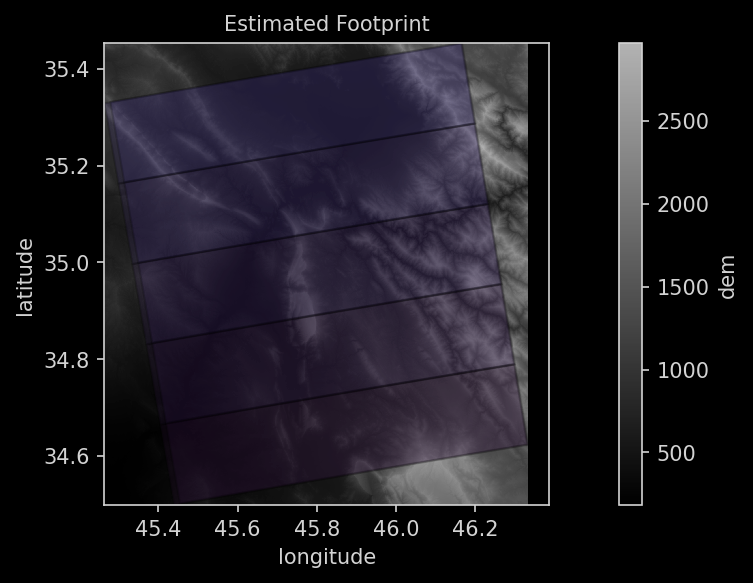

In [ ]:
# descending orbit bursts: preview
s1.plot(ref='2017-11-11')

In [ ]:
# load SLC bursts and orbits with DEM and transform to ZARR
s1.transform(ZARRDIR, ref='2017-11-11')

NOTE: EPSG code is computed automatically for all bursts: 32638.
NOTE: Using 5 workers for 5 bursts, 2 dates each (burst-parallel, scheduler=None).


Transforming SLC...      : 100%|██████████| 5/5 [01:26<00:00, 17.32s/it]


# Stage 2. InSAR.dev: A Python package for InSAR processing

Load Sentinel-1 geocoded, cloud-ready Zarr dataset locally or hosted on GitHub or any file storage as a set of files or a single ZIP archive.

## Load and Setup Python Modules

In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  #!{sys.executable} -m pip install -qq --progress-bar off insardev insardev-toolkit
  !{sys.executable} -m pip install -qq --progress-bar off \
    "insardev_toolkit  @ git+https://github.com/InSARdev/core@main#subdirectory=insardev_toolkit" \
    "insardev          @ git+https://github.com/InSARdev/core@main#subdirectory=insardev"
  !{sys.executable} -m pip install -qq --progress-bar off  "pyvista<0.49" xvfbwrapper jupyter_bokeh vtk panel
  #trame trame-vuetify trame-vtk
  from google.colab import output
  output.enable_custom_widget_manager()


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# import modules to be used in the notebook
from insardev import Stack
# data downloader
from insardev_toolkit.HTTP import unzip
from insardev_toolkit import UI, Tiles, XYZTiles
UI('dark')


In [ ]:
# common data science libraries
import xarray as xr
import numpy as np
import rioxarray as rio
import geopandas as gpd
import shapely


In [ ]:
# 3D plotting modules
import pyvista as pv
# white background
#pv.set_plot_theme("document")
pv.set_plot_theme("dark")
from IPython.display import display, HTML
if 'google.colab' in sys.modules:
    import panel
    panel.extension(comms='ipywidgets')
    panel.extension('vtk')

## Specify Directories

In [ ]:
ZARRDIR = 'iraniraq_zarr'
WORKDIR = 'iraniraq_workdir'
LAND= f'{WORKDIR}/land.nc'

### Epicentre


In [ ]:
# USGS epicentre of the 2017-11-12 Mw 7.3 Sarpol-e Zahab event.
# Defined here rather than carried over from Stage 1, so this half of the
# notebook runs on its own from the Zarr.
POI = gpd.GeoDataFrame(
    geometry=[shapely.geometry.Point(45.959, 34.911)]
).set_crs('EPSG:4326')
POI


,geometry
0,POINT (45.959 34.911)


## Download and Unpack Datasets

We can process datasets hosted on GitHub, Zenodo, or other platforms in a single workflow.

In [ ]:
# example downloading command
#unzip("https://zenodo.org/records/15347694/files/Türkiye_Elevation-40x10-004.zip", ZARRDIR)

## Run Local Dask Cluster

Launch a Dask cluster for local or distributed multicore computing. This makes it possible to process terabyte-scale Sentinel-1 SLC datasets even on an Apple MacBook Air with 16 GB of RAM.

In [ ]:
if 'client' in globals():
    client.shutdown()
    client.close()
import logging
logging.getLogger('distributed').setLevel(logging.CRITICAL)
from dask.distributed import Client
client = Client(silence_logs='CRITICAL', threads_per_worker=2, resources={'gpu': 1})
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 12,Total memory: 52.96 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41109,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45581,Total threads: 2
Dashboard: http://127.0.0.1:39485/status,Memory: 8.83 GiB
Nanny: tcp://127.0.0.1:46419,


## InSAR.dev Processing

In [ ]:
stack = Stack().load(ZARRDIR).align().chunk2d('32MB')
stack

Loading Dataset...       : 100%|██████████| 5/5 [00:04<00:00,  1.10it/s]


Stack containing 5 items for 2 date (072_152704_IW3 … 072_152708_IW3)

In [ ]:
stack.isel(0).data.VV

<xarray.DataArray 'VV' (date: 2, y: 2369, x: 21715)> Size: 823MB
dask.array<rechunk-merge, shape=(2, 2369, 21715), dtype=complex64, chunksize=(1, 2369, 1810), chunktype=numpy.ndarray>
Coordinates:
  * date         (date) datetime64[s] 16B 2017-11-11T15:00:17 2017-11-17T14:5...
  * y            (y) float32 9kB 3.816e+06 3.816e+06 ... 3.854e+06 3.854e+06
  * x            (x) float32 87kB 5.357e+05 5.357e+05 ... 6.225e+05 6.225e+05
    spatial_ref  int64 8B 0

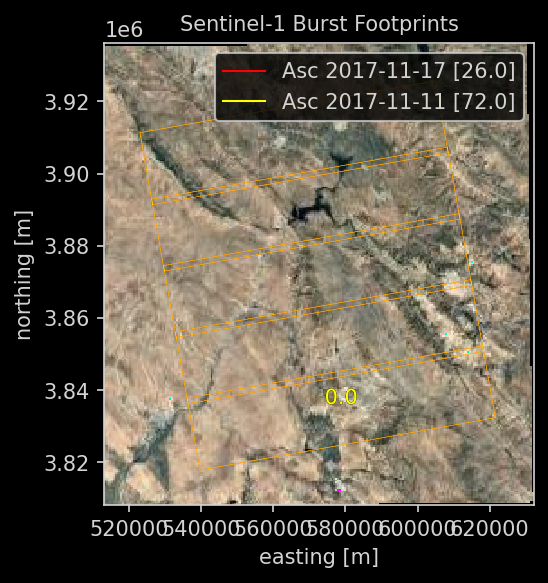

In [ ]:
# download the basemap adding the buffer to cover the area of interest after reprojecting
gmap = XYZTiles().download_googlesatellite(stack.to_dataframe().buffer(10_000), zoom=8, fill_value=0)
gmap.plot.imshow(ax=plt.gca(), zorder=-1, add_labels=False)
stack.plot(cmap='autumn', alpha=0.15, ax=plt.gca())
#plt.gca().set_title(f'Sentinel-1 Burst Footprints');

## Build Interferogram

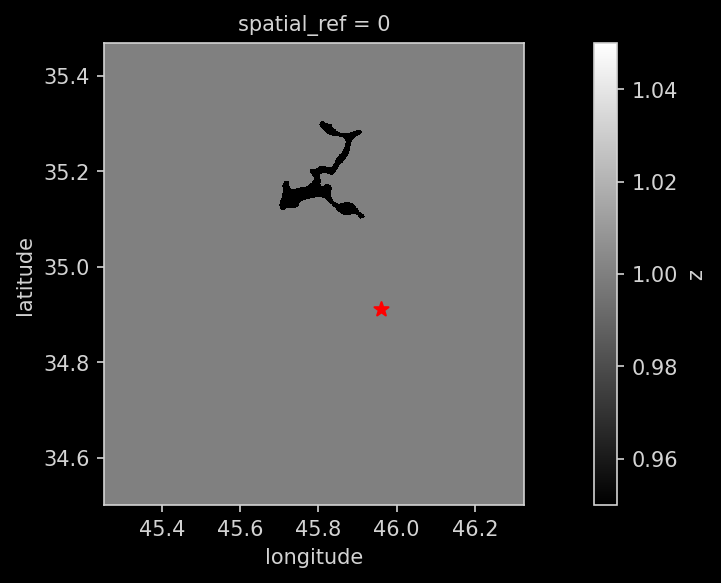

In [ ]:
# download land mask 1 arc-second over the loaded stack's own footprint.
Tiles().download_landmask(stack.to_dataframe(), filename=LAND, product='1s')[::4,::4].plot.imshow(cmap='binary_r')
POI.to_crs('EPSG:4326').plot(marker='*', color='red', markersize=50, ax=plt.gca());


In [ ]:
# load land mask and convert to binary mask
landmask = np.isfinite(xr.open_dataarray(LAND).rio.reproject(stack.crs))

In [ ]:
# Antialiasing Gaussian filter, adaptive Goldstein filter, then multilooking on the masked area.
intf, corr = stack.pairs([0, 1]).interferogram(200).goldstein(200).angle().mask(landmask).downsample(60).compute()
intf


Computing bursts         : 100%|██████████| 5620/5620 [00:17<00:00, 315.91it/s]


BatchWrap containing 5 items for 1 pair (072_152704_IW3 … 072_152708_IW3)

In [ ]:
# align and unify bursts
intf = intf.dissolve().compute()
corr = corr.dissolve().compute()

Computing Batch...       : 100%|██████████| 3514/3514 [00:00<00:00, 17366.51it/s]


Computing VV Plot        : 100%|██████████| 4423/4423 [00:00<00:00, 44620.68it/s]


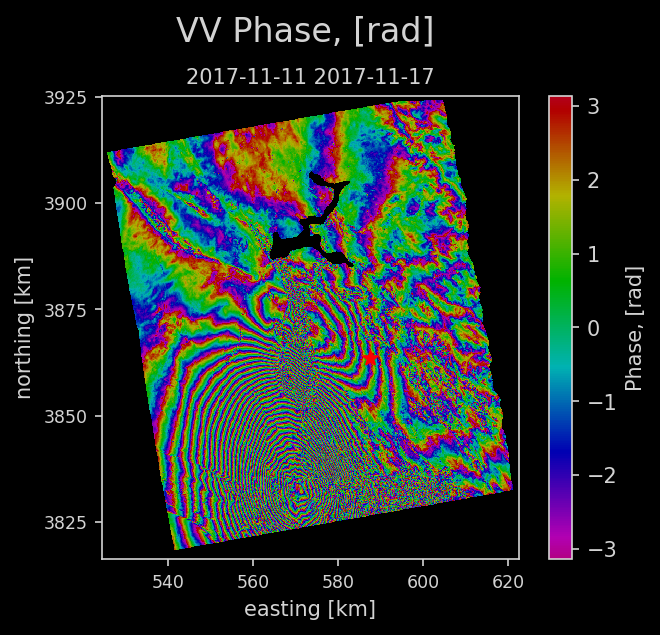

In [ ]:
intf.plot()
POI.to_crs(stack.crs).plot(marker='*', color='red', markersize=50, ax=plt.gca());


Computing VV Plot        : 100%|██████████| 3521/3521 [00:00<00:00, 2662366.03it/s]


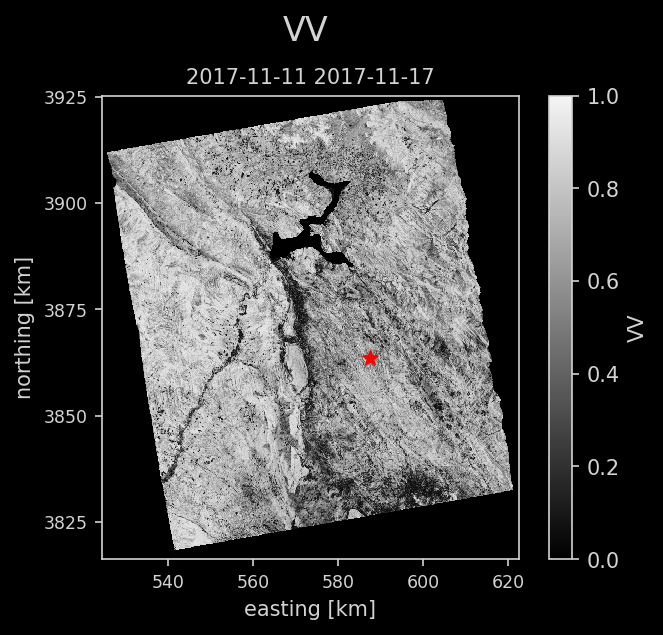

In [ ]:
corr.plot()
POI.to_crs(stack.crs).plot(marker='*', color='red', markersize=50, ax=plt.gca());


## Unwrap Interferogram to Phase

In [ ]:
# UNWRAP THE BURSTS AS ONE RASTER. `union=True` merges them, solves once over
# the result and hands each burst back holding only its own pixels, so the
# answer is consistent across burst edges.
phase = intf.unwrap2d(corr, union=True).compute()
phase


Computing Batch...       : 100%|██████████| 5906/5906 [00:01<00:00, 3659.33it/s] 


Batch containing 5 items for 1 pair (072_152704_IW3 … 072_152708_IW3)

Computing VV Plot        : 100%|██████████| 5913/5913 [00:00<00:00, 1662928.76it/s]


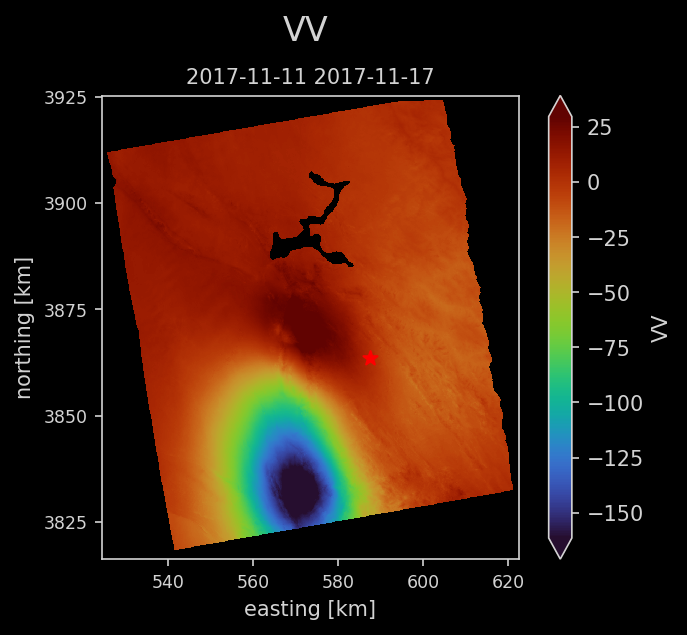

In [ ]:
phase.plot(quantile=[0.01, 0.99], alpha=0.8)
POI.to_crs(stack.crs).plot(marker='*', color='red', markersize=50, ax=plt.gca());


## Convert Phase to Displacement

In [ ]:
los = phase.displacement_los(stack.transform())

Computing VV Plot        : 100%|██████████| 5918/5918 [00:00<00:00, 59073.86it/s]


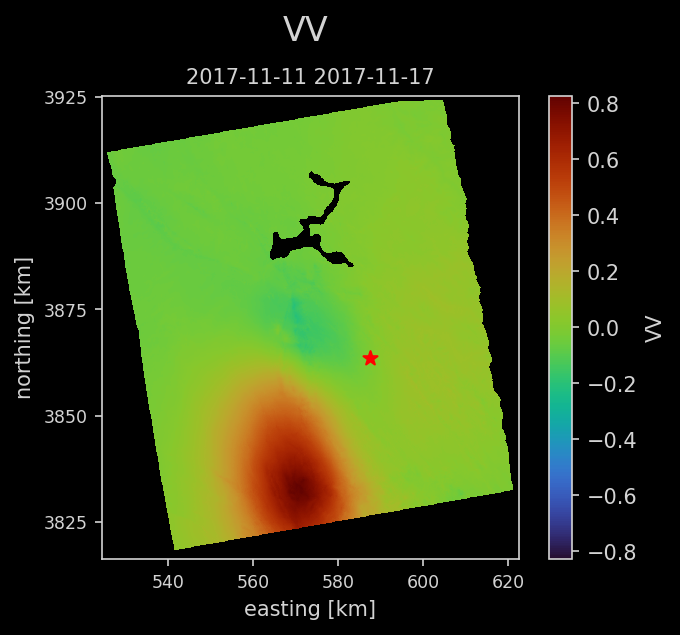

In [ ]:
los.plot(alpha=0.8)
POI.to_crs(stack.crs).plot(marker='*', color='red', markersize=50, ax=plt.gca());


## 3D Interactive Map

In [ ]:
intf.downsample(120).to_vtk('intf', stack.transform()[['ele']].downsample(120))
los.downsample(120).to_vtk('los', stack.transform()[['ele']].downsample(120))

Exporting VTK: 100%|██████████| 1/1 [00:00<00:00,  2.74it/s]


In [ ]:
# build interactive 3D plot
plotter = pv.Plotter(shape=(1, 2), notebook=True)

plotter.subplot(0, 0)
mesh = pv.read('intf/VV.vtk').scale([1, 1, 1], inplace=True)
plotter.add_mesh(mesh, scalars='20171111_20171117', cmap='turbo', ambient=0.1, show_scalar_bar=True, scalar_bar_args={'title': 'Interferogram [rad]'})
bounds = mesh.bounds
center = mesh.center
# move camera closer by reducing distance (zoom in)
distance = mesh.length / 1.4
plotter.camera.position = (center[0] + distance, center[1] + distance, center[2] + distance * 0.5)
plotter.camera.focal_point = center
plotter.camera.azimuth = 215
plotter.camera.elevation = 15

plotter.subplot(0, 1)
mesh = pv.read('los/VV.vtk').scale([1, 1, 1], inplace=True)
plotter.add_mesh(mesh, scalars='20171111_20171117', cmap='turbo', ambient=0.1, show_scalar_bar=True, scalar_bar_args={'title': 'LOS displacement [m]'})
bounds = mesh.bounds
center = mesh.center
# move camera closer by reducing distance (zoom in)
distance = mesh.length / 1.4
plotter.camera.position = (center[0] + distance, center[1] + distance, center[2] + distance * 0.5)
plotter.camera.focal_point = center
plotter.camera.azimuth = 215
plotter.camera.elevation = 15

#plotter.show_axes()
plot = plotter.show(screenshot='3D Elevation.png', jupyter_backend='panel' if 'google.colab' in sys.modules else 'client', return_viewer=True)
if 'google.colab' in sys.modules:
    plot = panel.panel(
        plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
        enable_keybindings=False, sizing_mode='stretch_width', min_height=600
    )
display(HTML('<h1 style="text-align:center; margin-bottom:0;">Sentinel-1 Interferogram and LOS Displacement on DEM, meters</h1>'))
plot

## Compare Results to PyGMTSAR, GMTSAR, GAMMA, SNAP

- **InSAR.dev** displacement calculated below is 0.829-(-0.219) = 104.8 cm.

- **PyGMTSAR** LOS displacement in [Iran–Iraq Earthquake (2017) notebook](https://colab.research.google.com/drive/1shNGvUlUiXeyV7IcTmDbWaEM6XrB0014?usp=sharing) is equal to **750 mm + 283 mm = 103.3 cm**. It can vary by about one fringe depending on single-frame or tiled unwrapping and the selection of bursts or full subswath.

- **GAMMA software package results**: [Co-Seismic Deformation and Fault Slip Model of the 2017 Mw 7.3 Darbandikhan, Iran-Iraq Earthquake Inferred from D-InSAR Measurements](https://www.mdpi.com/2072-4292/11/21/2521/htm). The reported amplitude is **84 cm + 15 cm = 99 cm**.

- **GMTSAR results**: [Surface Displacements of the 12 November 2017 Iran – Iraq Earthquake derived using SAR Interferometry](https://www.researchgate.net/publication/333108916_Surface_Displacements_of_the_12_November_2017_Iran_-_Iraq_Earthquake_derived_using_SAR_Interferometry). The reported amplitude is **80 cm + 22 cm = 102 cm**.

- **SNAP processing instructions and output interferogram**: [Creating Interferogram for Mapping Earthquake Deformation by using Sentinel-1 Data in SNAP](https://dges.carleton.ca/CUOSGwiki/index.php/Creating_Interferogram_for_Mapping_Earthquake_Deformation_by_using_Sentinel-1_Data_in_SNAP). While no unwrapping processing is performed here, we can compare the interferograms—see plots below.

In [ ]:
# measure LOS Displacement, [m]
np.array(los.to_dataset().VV.min().round(3)), np.array(los.to_dataset().VV.max().round(3))

(array(-0.212, dtype=float32), array(0.828, dtype=float32))

### Download SNAP Interferogram

In [ ]:
# check if the file is downloaded
import os
import requests
from PIL import Image
from io import BytesIO

f, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4), dpi=300)
intf.to_dataset().VV[0].plot.imshow(vmin=-np.pi, vmax=np.pi, alpha=0.7, cmap='gist_rainbow_r', ax=ax1)
ax1.set_title('InSAR.dev Phase, [rad]', fontsize=18)

img = Image.open(BytesIO(requests.get('https://dges.carleton.ca/CUOSGwiki/images/thumb/b/b1/Step12_II.JPG/1400px-Step12_II.JPG').content))
ax2.imshow(img)
ax2.axis('off')
ax2.set_title('SNAP Cropped IW3 Phase, [rad]', fontsize=18)

plt.show()

## Save the Results

Save the results in geospatial data formats like to NetCDF, GeoTIFF and others. The both formats (NetCDF and GeoTIFF) can be opened in QGIS and other GIS applications.

In [ ]:
los.to_dataset().VV[0].rio.to_raster('los.tif')
#los.to_dataset().VV[0].to_netcdf('los.nc')

## Export from Google Colab

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download('los.tif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>